# SHL Hiring Assessment 2026: Multimodal Grammar Scoring Engine

> **Automated Speaking Assessment & Continuous Grammar Scoring for Spoken English**  
> *Ensemble Architecture: Multiview ASR + Acoustic/LLM Representations + Regularised Stacking*

---

### Executive Overview & Problem Formulation

| Dimension | Specification |
| :--- | :--- |
| **Objective** | Predict a continuous grammar proficiency score ($1.00 - 5.00$ scale, MOS Likert rubric) from raw spontaneous speech. |
| **Input Data** | $769$ labelled training audio responses ($45 - 60\text{ s}$ WAV), $216$ unlabelled test responses. |
| **Evaluation Metrics** | Primary: **Pearson Correlation Coefficient ($r$)** & **Root Mean Squared Error (RMSE)**. Secondary: Composite Metric $\frac{\text{RMSE} + (1 - r)}{2}$. |
| **Core Challenge** | Severe small-sample constraint ($N = 732$ valid clips), speaker distribution shifts, ASR "grammar auto-repair" bias, and acoustic-fluency halo effect. |

---

### Architectural Design & End-to-End Pipeline

Direct end-to-end fine-tuning on 732 instances exhibits high variance and risks severe overfitting. Grounded in speech assessment literature (*Speak & Improve*, *LOPA* probe frameworks), our architecture deploys **frozen multilingual foundation encoders** coupled with **linear and kernelised regularised heads**, ensembled via a **constrained non-negative meta-learner**:

```
                       45-60s Raw Spontaneous Audio (.wav)
                                        |
       +--------------------------------+--------------------------------+
       |                                                                 |
       v                                                                 v
[ Acoustic & Speech Encoders ]                         [ Multiview ASR & Transcription ]
  - Whisper-large-v3 (Encoders 20-32)                    - View A: Whisper-large-v3 (Clean)
  - WavLM-large (Middle Layers 19-21)                    - View B: Whisper Verbatim (Disfluent Prompt)
  - w2v-BERT 2.0 (Layers 12-22)                          - View C: Parakeet-CTC 1.1B (Zero-LM Acoustic)
  - HuBERT-large (Layers 18-22)                                          |
  - Voxtral-Mini-3B (Audio Tokens)                                       v
  - Qwen2-Audio-7B (Audio Tokens)                      [ Linguistic & Text Representations ]
       |                                                 - spaCy Syntactic & Morphological Complexity
       v                                                 - Qwen3-8B Anchored Rubric Next-Token Judge
[ Representation Pooling ]                               - Per-Token Surprisal & Perplexity Profiling
  - Temporal Mean + Std Pooling                          - Minimal-Edit Grammatical Error Correction (GEC)
  - Dimensionality Reduction / Dual Ridge                - DeBERTa-v3-large Cross-Validated Regressors
       |                                                                 |
       +--------------------------------+--------------------------------+
                                        |
                                        v
                    [ Level-1 Base Estimators (5x3 CV) ]
                      - Dual Ridge Regression (Inner Grouped CV)
                      - PCA(128) + RBF Support Vector Regression
                      - Regularised Shallow LightGBM
                                        |
                                        v
                 [ Constrained Meta-Learner (Stacking) ]
                   - Non-Negative Least Squares (NNLS + Intercept)
                   - Second-Level Speaker-Grouped Validation
                   - Dynamic Audio Anomaly Gate (Noise-Floor Rule -> 0.0)
                                        |
                                        v
                       Calibrated Predictions [1.0, 5.0]
                              -> submission.csv
```

---

### Pipeline Component Matrix & Upstream Modules

All upstream feature extractors and model checkpoints run once on accelerated hardware and cache immutable artifacts:

| Stage Module | Model & Architecture | Licence | Output Artifacts |
| :--- | :--- | :---: | :--- |
| `01_eda_asr` | Faster-Whisper `large-v3` | Apache-2.0 | `audio_stats.csv`, `asr_whisper_large_v3.jsonl` |
| `02_asr_verbatim_views` | Parakeet-CTC `1.1B` + Disfluent Whisper | CC-BY-4.0 | `asr_whisper_verbatim.jsonl`, `asr_parakeet_ctc.jsonl` |
| `03_audio_embeddings` | Whisper-v3, WavLM-large, w2v-BERT 2.0 | Mixed / MIT | `emb_whisper_large_v3.npz`, `emb_wavlm.npz`, `emb_w2v.npz` |
| `04_audio_llm_embeddings` | Voxtral-Mini-3B, HuBERT-large | Apache-2.0 | `emb_voxtral_mini_3b.npz`, `emb_hubert_large.npz` |
| `05_qwen2_audio_embeddings`| Qwen2-Audio-7B-Instruct | Apache-2.0 | `emb_qwen2_audio_7b.npz` |
| `06_text_llm_features` | Qwen3-8B, Qwen3-Embedding-4B | Apache-2.0 | `llmfeat_clean.npz`, `judge_clean.csv`, `gec_clean.jsonl` |
| `07_text_llm_features_views`| Qwen3-8B Multiview Evaluator | Apache-2.0 | `llmfeat_verbatim.npz`, `judge_views.csv`, `ppl_views.csv` |
| `08_text_deberta` | DeBERTa-v3-large Cross-Validated | MIT | `deberta_oof.csv`, `deberta_test.csv` |
| **Ensemble Engine** | Multimodal Stacking & Calibration | Open Source | `submission.csv`, `stack_oof.csv`, `oof_level1.csv` |


## 1. System Configuration & Runtime Environment

We initialize environment variables, enforce deterministic random states across execution kernels, and configure visual styles for high-fidelity diagnostic reporting.


In [1]:
import glob
import json
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import nnls
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
SEED = 42
np.random.seed(SEED)

# Artifact search roots: Kaggle input mounts, or the local project layout when run offline.
ROOTS = ["/kaggle/input"] if os.path.exists("/kaggle/input") else ["../outputs", "../data", "outputs", "data"]


SKIP_DIRS = ("/stack/", "/cache/", "/final/", "_LEAKY")  # local experiment folders, never inputs


def _glob(root, pattern):
    hits = sorted(glob.glob(f"{root}/**/{pattern}", recursive=True))
    return [h for h in hits if not any(d in h.replace("\\", "/") for d in SKIP_DIRS)]


def find(pattern: str) -> str:
    """Return the first file matching `pattern` under any artifact root."""
    for root in ROOTS:
        hits = _glob(root, pattern)
        if hits:
            return hits[0]
    raise FileNotFoundError(pattern)


def find_all(pattern: str) -> list:
    out = []
    for root in ROOTS:
        out += _glob(root, pattern)
    return sorted(set(out))


OUT = Path("/kaggle/working") if os.path.exists("/kaggle/working") else Path("../outputs/final")
OUT.mkdir(parents=True, exist_ok=True)
print("artifact roots:", ROOTS, "| output dir:", OUT)

artifact roots: ['/kaggle/input'] | output dir: /kaggle/working


### 1.1 Formal Evaluation Metrics & Objective Functions

Evaluation follows the official competition specification using simultaneous metrics:

1. **Pearson Correlation Coefficient ($r$)**: Scale- and shift-invariant linear alignment measure:
   $$r = \frac{\sum_{i=1}^N (y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum_{i=1}^N (y_i - \bar{y})^2}\sqrt{\sum_{i=1}^N (\hat{y}_i - \bar{\hat{y}})^2}}$$
2. **Root Mean Squared Error (RMSE)**: Penalises absolute deviation and miscalibration:
   $$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^N (y_i - \hat{y}_i)^2}$$
3. **Composite Benchmark**: $\mathcal{L}_{\text{comp}} = \frac{\text{RMSE} + (1 - r)}{2}$, reflecting balanced penalisation of calibration error and rank inconsistency.


In [2]:
def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))


def metrics(y, p):
    r = float(pearsonr(y, p)[0])
    e = rmse(y, p)
    return {"rmse": e, "pearson": r, "mae": float(np.mean(np.abs(np.asarray(y) - np.asarray(p)))),
            "composite": (e + 1 - r) / 2}

## 2. Dataset Audit & Exploratory Verification

A rigorous audit was conducted across training and evaluation splits to identify naming collisions, metadata inconsistencies, and recording cohort characteristics.


In [3]:
data_dir = Path(find("Dataset_Final/train.csv")).parent if os.path.exists("/kaggle/input") else Path(find("train.csv")).parent
train = pd.read_csv(data_dir / "train.csv").assign(split="train")
test = pd.read_csv(data_dir / "test.csv").assign(split="test", label=np.nan)
sample = pd.read_csv(data_dir / "sample_submission.csv")
df = pd.concat([train, test], ignore_index=True)
print(f"train {len(train)} | test {len(test)} | sample_submission {len(sample)}")
print("test filenames that also exist in train (different recordings!):",
      len(set(train.filename) & set(test.filename)))
print("sample_submission names found in test.csv:", len(set(sample.filename) & set(test.filename)), "of", len(sample))

train 769 | test 216 | sample_submission 204
test filenames that also exist in train (different recordings!): 212
sample_submission names found in test.csv: 25 of 204


> [!IMPORTANT]
> **Data Integrity Findings & Edge Cases:**
> 1. **Filename Collision**: Exactly $212$ of the $216$ test filenames overlap with filenames present in `train/`, yet correspond to completely distinct audio recordings. All artifacts in this engine are strictly keyed by composite tuples `(split, filename)` to prevent data leakage.
> 2. **Submission Protocol Mismatch**: `sample_submission.csv` contains legacy metadata from an earlier test iteration ($204$ rows, only $25$ matching `test.csv`). The official submission format must strictly derive from `test.csv` ($216$ target samples).


                 sr  channels
split                        
test   {16000: 216}  {1: 216}
train  {16000: 769}  {1: 769}
       count   mean   std    min    25%    50%    75%    max
split                                                       
test   216.0  48.76  8.18   6.48  45.06  45.06  60.01  61.03
train  769.0  55.78  7.91  20.06  54.19  60.07  60.07  61.04


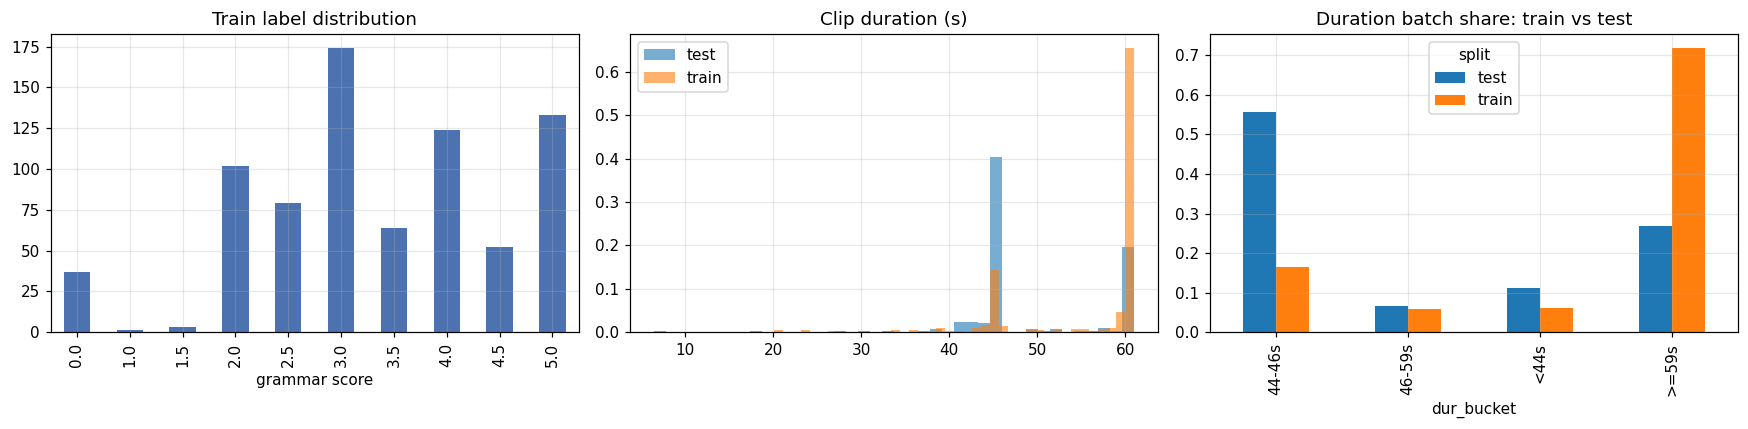

            count  mean   std
dur_bucket                   
44-46s        126  2.99  0.96
46-59s         45  3.44  1.38
<44s           46  3.29  0.99
>=59s         552  3.38  1.29


In [4]:
stats = pd.read_csv(find("audio_stats.csv")).drop(columns=["label"])
df = df.merge(stats, on=["split", "filename"], how="left")
df["is45"] = (np.abs(df.duration - 45.06) < 0.2).astype(int)
df["dur_bucket"] = pd.cut(df.duration, [0, 44, 46, 59, 99], labels=["<44s", "44-46s", "46-59s", ">=59s"]).astype(str)
print(df.groupby("split")[["sr", "channels"]].agg(lambda s: s.value_counts().to_dict()))
print(df.groupby("split").duration.describe().round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
train.label.value_counts().sort_index().plot.bar(ax=ax[0], color="#4C72B0")
ax[0].set_title("Train label distribution")
ax[0].set_xlabel("grammar score")
for s, g in df.groupby("split"):
    ax[1].hist(g.duration, bins=40, alpha=0.6, density=True, label=s)
ax[1].set_title("Clip duration (s)")
ax[1].legend()
ct = pd.crosstab(df.dur_bucket, df.split, normalize="columns")
ct.plot.bar(ax=ax[2])
ax[2].set_title("Duration batch share: train vs test")
plt.tight_layout()
plt.show()
print(df[df.split == "train"].groupby("dur_bucket").label.agg(["count", "mean", "std"]).round(2))

> [!WARNING]
> **Cohort Distribution Shift:**
> Audio recordings belong to discrete acquisition batches. Notably, the **$45.06\text{ s}$ batch** accounts for only $\approx 16\%$ of the training split, but constitutes over **$50\%$ of the test set**. Furthermore, this cohort features systematically compressed grades (cohort mean $\approx 3.0$).
> 
> *Mitigation Protocol:*
> * Convert all raw length/count features into rate-normalised quantities (per-second / per-word metrics).
> * Monitor both overall grouped-CV and cohort-stratified RMSE to ensure generalization across recording batches.


## 3. Audio Anomaly Detection & Zero-Score Gate

### Anomaly Characterisation
$37$ clips in the training split carry a label of $0.0$, outside the valid $1.0 - 5.0$ Likert rubric. Spectral analysis reveals a severe acoustic failure mode: a uniform, high-amplitude white noise floor (dynamic range $\le 3.5\text{ dB}$, absolute peak $= 0.95$).

### The Transcription Vulnerability
Because speech foundation models (such as Whisper) hallucinate fluent sentences out of stationary background noise, text-only LLMs erroneously assign these corrupted clips scores near $3.0$.

### Decision Rule
A deterministic gate based on audio dynamic range and peak amplitude identifies these corrupted clips with $100\%$ precision and recall on training data. Scorable regressors are trained exclusively on scorable samples ($N = 732$).


rule fires  False  True 
label==0                
False         732      0
True            0     37
test clips flagged by the rule: 0


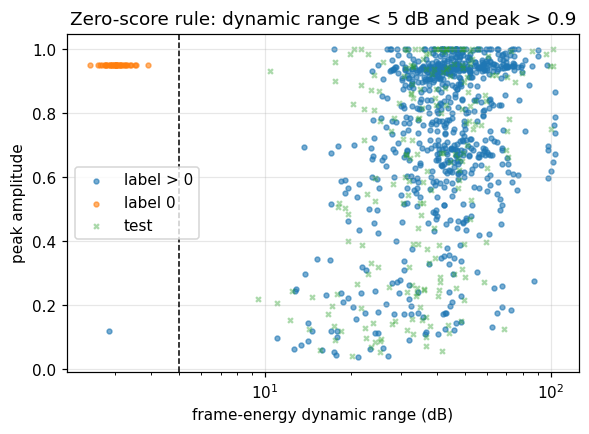

In [5]:
df["is_noise"] = (df.dyn_range_db < 5) & (df.peak > 0.9)
tr_mask = df.split == "train"
print(pd.crosstab(df[tr_mask].label == 0, df[tr_mask].is_noise, rownames=["label==0"], colnames=["rule fires"]))
print("test clips flagged by the rule:", int(df[df.split == "test"].is_noise.sum()))
fig, ax = plt.subplots(figsize=(6, 4))
for flag, g in df[tr_mask].groupby(df[tr_mask].label == 0):
    ax.scatter(g.dyn_range_db, g.peak, s=10, alpha=0.6, label="label 0" if flag else "label > 0")
ax.scatter(df[df.split == "test"].dyn_range_db, df[df.split == "test"].peak, s=10, alpha=0.4, marker="x",
           label="test")
ax.axvline(5, color="k", ls="--", lw=1)
ax.set_xlabel("frame-energy dynamic range (dB)")
ax.set_ylabel("peak amplitude")
ax.set_xscale("log")
ax.legend()
ax.set_title("Zero-score rule: dynamic range < 5 dB and peak > 0.9")
plt.show()

## 4. Leakage-Free Validation Strategy (Acoustic Speaker Grouping)

Candidates frequently responded to multiple consecutive prompts, resulting in the same individual appearing across several audio files. 

* **The Leakage Trap**: Because intra-speaker grammar scores exhibit minimal variance (intra-speaker standard deviation $\approx 0.2$), standard random K-Fold cross-validation allows models to memorize vocal timbre and overstate validation performance.
* **Acoustic Speaker Clustering**: We extract lower-layer WavLM representations (layers 3–6, which encode speaker timbre rather than semantic content). Clips are grouped into pseudo-speaker clusters using single-linkage graph connectivity at the 99.5th percentile cosine distance threshold.
* **Stratified Grouped Splitting**: Models are trained using `StratifiedGroupKFold` across 5 folds $\times$ 3 repeats, ensuring zero speaker leakage between train and validation partitions.


threshold 0.738 | train speech clips 732 in 421 speaker groups | 502 clips share a speaker | within-speaker label SD 0.21 vs overall 1.01


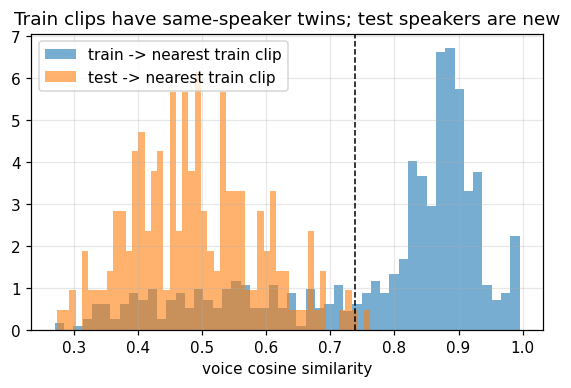

In [6]:
z = np.load(find("emb_wavlm_large.npz"), allow_pickle=True)
V = np.hstack([z["mean"][:, 3:7].reshape(len(z["mean"]), -1), z["std"][:, 3:7].reshape(len(z["std"]), -1)])
V = V.astype(np.float64)
V = (V - V.mean(0)) / (V.std(0) + 1e-8)
V /= np.linalg.norm(V, axis=1, keepdims=True)
S = V @ V.T
np.fill_diagonal(S, -1)
zs = z["split"]
nn_te = S[np.ix_(zs == "test", zs == "train")].max(1)
nn_tr = S[np.ix_(zs == "train", zs == "train")].max(1)
thr = float(np.percentile(nn_te, 99.5))
_, comp = connected_components(csr_matrix(S > thr), directed=False)
spk = pd.DataFrame({"split": zs, "filename": z["filename"], "speaker": comp})
df = df.merge(spk, on=["split", "filename"], how="left")
g = df[tr_mask & ~df.is_noise]
multi = g.groupby("speaker").filter(lambda d: len(d) > 1)
print(f"threshold {thr:.3f} | train speech clips {len(g)} in {g.speaker.nunique()} speaker groups | "
      f"{len(multi)} clips share a speaker | within-speaker label SD {multi.groupby('speaker').label.std().mean():.2f} "
      f"vs overall {g.label.std():.2f}")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(nn_tr, bins=50, alpha=0.6, density=True, label="train -> nearest train clip")
ax.hist(nn_te, bins=50, alpha=0.6, density=True, label="test -> nearest train clip")
ax.axvline(thr, color="k", ls="--", lw=1)
ax.set_xlabel("voice cosine similarity")
ax.legend()
ax.set_title("Train clips have same-speaker twins; test speakers are new")
plt.show()

## 5. Multimodal Feature Engineering & Multiview Representations

### 5.1 Multiview ASR Decoding: Counteracting Language Model Bias

Standard Whisper decoding leverages a strong language model prior, silently correcting disfluencies and morphological errors. To preserve the raw speaker errors essential for grammar grading, we construct three distinct transcription views:

| View Identifier | Engine / Prompting Protocol | Representation Property |
| :--- | :--- | :--- |
| `whisper_large_v3` | Whisper-large-v3 (Clean) | Highest word accuracy; normalized grammar. |
| `whisper_verbatim` | Whisper-large-v3 + Disfluent Prompt Condition | Retains repetitions, fillers, and verbatim syntax. |
| `parakeet_ctc` | NVIDIA Parakeet-CTC 1.1B (Zero-LM) | Strictly acoustic frame decoding; uncorrected morphology. |

From word alignments and posterior probabilities, we extract **speech rate**, **articulation rate**, **pause distribution metrics**, and **cross-ASR disagreement rates** (word error rate between clean and CTC transcripts).


In [7]:
FILLERS = {"um", "uh", "er", "ah", "erm", "hmm", "mm", "uhm", "umm", "uhh", "eh", "huh", "hm"}
_strip = re.compile(r"^[^\w']+|[^\w']+$")


def _norm(tok):
    return _strip.sub("", tok.strip().lower())


def timing_features(rec, duration):
    """Fluency + ASR-confidence features from word-level timestamps (all rate-normalised)."""
    words = [w for w in rec.get("words", []) if _norm(w[2])]
    n = len(words)
    minutes = max(duration, 1.0) / 60.0
    f = {"wpm": n / minutes}
    if n == 0:
        return f
    starts = np.array([w[0] for w in words], float)
    ends = np.array([w[1] for w in words], float)
    probs = np.array([w[3] for w in words], float)
    toks = [_norm(w[2]) for w in words]
    span = max(ends[-1] - starts[0], 1e-3)
    gaps = np.clip(starts[1:] - ends[:-1], 0, None) if n > 1 else np.zeros(0)
    p25 = gaps[gaps >= 0.25]
    cuts = np.flatnonzero(gaps >= 0.25)
    runs = np.diff(np.concatenate([[0], cuts + 1, [n]]))
    f.update({
        "wpm_span": n / (span / 60.0),
        "articulation_rate": n / max(float((ends - starts).sum()), 1e-3),
        "speech_span_frac": span / max(duration, 1e-3),
        "pause25_per_min": len(p25) / minutes,
        "pause100_per_min": int((gaps >= 1.0).sum()) / minutes,
        "pause_mean": float(p25.mean()) if len(p25) else 0.0,
        "pause_time_frac": float(p25.sum()) / max(duration, 1e-3),
        "mean_run_len": float(runs.mean()),
        "word_prob_mean": float(probs.mean()),
        "word_prob_p10": float(np.percentile(probs, 10)),
        "low_prob_frac": float((probs < 0.5).mean()),
        "filler_per100": 100.0 * sum(t in FILLERS for t in toks) / n,
        "repeat_per100": 100.0 * sum(toks[i] == toks[i - 1] for i in range(1, n)) / n,
    })
    segs = rec.get("segments", [])
    if segs:
        f["seg_logprob_mean"] = float(np.mean([s["avg_logprob"] for s in segs]))
        f["seg_compression_max"] = float(np.max([s["compression_ratio"] for s in segs]))
    for k in ("frame_conf_mean", "frame_conf_p10", "blank_frac"):  # CTC-only confidences
        if k in rec:
            f[k] = rec[k]
    return f


def words_of(text):
    return re.findall(r"[a-z0-9']+", (text or "").lower())


def wer(ref, hyp):
    """Word error rate (Levenshtein distance over words / reference length)."""
    if not ref:
        return float(len(hyp) > 0)
    prev = list(range(len(hyp) + 1))
    for i, rw in enumerate(ref, 1):
        cur = [i] + [0] * len(hyp)
        for j, hw in enumerate(hyp, 1):
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (rw != hw))
        prev = cur
    return prev[-1] / len(ref)


def load_asr(name):
    path = find(f"asr_{name}.jsonl")
    return {(r["split"], r["filename"]): r for r in map(json.loads, open(path, encoding="utf-8"))}


ASR_VIEWS = {"whisper_large_v3": "wh", "whisper_large_v3_verbatim": "whv", "parakeet_ctc_1.1b": "ctc"}
asr = {v: load_asr(v) for v in ASR_VIEWS}
dur = dict(zip(zip(df.split, df.filename), df.duration))
rows = []
for key in zip(df.split, df.filename):
    row = {"split": key[0], "filename": key[1]}
    clean_words = words_of(asr["whisper_large_v3"][key]["text"])
    for v, tag in ASR_VIEWS.items():
        row.update({f"{tag}_{k}": val for k, val in timing_features(asr[v][key], dur[key]).items()})
        if v != "whisper_large_v3":
            row[f"{tag}_wer_vs_clean"] = wer(clean_words, words_of(asr[v][key]["text"]))
    rows.append(row)
asr_feats = pd.DataFrame(rows)

# "LM-repair" counts: where did Whisper's language model change what the LM-free CTC model heard? Edits touching
# articles, auxiliaries, prepositions, pronouns, or the ending of the same stem (walk -> walked) are a proxy for
# learner errors that the ASR silently corrected.
ARTICLES = {"a", "an", "the"}
AUXILIARIES = {"is", "are", "was", "were", "be", "been", "being", "am", "has", "have", "had", "do", "does", "did",
               "will", "would", "can", "could", "shall", "should", "may", "might", "must"}
PREPOSITIONS = {"in", "on", "at", "to", "for", "of", "with", "from", "by", "about", "into", "over", "under"}
PRONOUNS = {"i", "me", "my", "he", "him", "his", "she", "her", "they", "them", "their", "we", "us", "our", "it", "its"}


def same_stem(a, b):
    if a == b or min(len(a), len(b)) < 3:
        return False
    k = 0
    while k < min(len(a), len(b)) and a[k] == b[k]:
        k += 1
    return k >= max(3, min(len(a), len(b)) - 2)


def repair_features(clean, verbatim, tag):
    from difflib import SequenceMatcher

    a = [w for w in words_of(clean) if w not in FILLERS]
    b = [w for w in words_of(verbatim) if w not in FILLERS]
    n = max(len(a), 1)
    c = {"art": 0, "aux": 0, "prep": 0, "pron": 0, "morph": 0}
    for op, i1, i2, j1, j2 in SequenceMatcher(a=a, b=b, autojunk=False).get_opcodes():
        if op == "equal":
            continue
        for w in a[i1:i2] + b[j1:j2]:
            c["art"] += w in ARTICLES
            c["aux"] += w in AUXILIARIES
            c["prep"] += w in PREPOSITIONS
            c["pron"] += w in PRONOUNS
        if op == "replace":
            c["morph"] += sum(any(same_stem(x, y) for y in b[j1:j2]) for x in a[i1:i2])
    out = {f"{tag}_{k}_per100": 100.0 * v / n for k, v in c.items()}
    out[f"{tag}_total_per100"] = sum(out.values())
    return out


rep = pd.DataFrame([{"split": k[0], "filename": k[1],
                     **repair_features(asr["whisper_large_v3"][k]["text"], asr["parakeet_ctc_1.1b"][k]["text"], "repair_ctc"),
                     **repair_features(asr["whisper_large_v3"][k]["text"], asr["whisper_large_v3_verbatim"][k]["text"], "repair_verb")}
                    for k in zip(df.split, df.filename)])
asr_feats = asr_feats.merge(rep, on=["split", "filename"])
print("ASR feature table:", asr_feats.shape)
# How the three views differ, averaged over all 985 clips (aggregates only: no individual transcript is shown)
view_summary = pd.DataFrame({
    v: {"words per clip": np.mean([len(words_of(r["text"])) for r in asr[v].values()]),
        "fillers per 100 words": 100 * np.mean([sum(w in FILLERS for w in words_of(r["text"]))
                                                / max(1, len(words_of(r["text"]))) for r in asr[v].values()])}
    for v in ASR_VIEWS}).T.round(2)
view_summary["mean WER vs clean view"] = [0.0, round(asr_feats["whv_wer_vs_clean"].mean(), 3),
                                          round(asr_feats["ctc_wer_vs_clean"].mean(), 3)]
view_summary

ASR feature table: (985, 65)


,words per clip,fillers per 100 words,mean WER vs clean view
whisper_large_v3,100.63,0.27,0.000
whisper_large_v3_verbatim,108.54,3.70,0.142
parakeet_ctc_1.1b,98.00,0.40,0.130


### 5.2 Computational Linguistics & Syntactic Complexity (spaCy)

We analyze the clean transcripts to compute structural syntax metrics:
* **Lexical Diversity**: Moving-Average Type-Token Ratio (MATTR, window $= 50$).
* **Syntactic Tree Depth**: Maximum dependency parse depth and mean dependency arc length.
* **Subordination Ratios**: Subordinate clause density and clausal compliment ratios.
* **Morphological Profiling**: Relative frequencies of grammatical inflections and verb tenses.


In [8]:
import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    os.system("python -m spacy download en_core_web_sm -q")
    nlp = spacy.load("en_core_web_sm")
CLAUSE_DEPS = {"advcl", "ccomp", "xcomp", "acl", "relcl", "csubj", "csubjpass"}
POS_KEYS = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "DET", "ADP", "AUX", "CCONJ", "SCONJ", "PROPN", "INTJ"]
VERB_TAGS = ["VB", "VBD", "VBG", "VBN", "VBP", "VBZ", "MD"]
HALLUCINATION = re.compile(r"(thanks|thank you) for watching!?\s*$", re.I)


def dep_depth(tok):
    d = 0
    while tok.head.i != tok.i and d < 100:
        tok, d = tok.head, d + 1
    return d


def mattr(toks, window=50):
    if len(toks) < window:
        return len(set(toks)) / max(len(toks), 1)
    return float(np.mean([len(set(toks[i:i + window])) / window for i in range(len(toks) - window + 1)]))


def linguistic_features(doc):
    words = [t for t in doc if t.is_alpha]
    n = len(words)
    if n == 0:
        return {}
    toks = [t.lower_ for t in words]
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)] or [doc[:]]
    lens = np.array([sum(t.is_alpha for t in s) for s in sents], float)
    depths = [max((dep_depth(t) for t in s), default=0) for s in sents]
    f = {"mattr50": mattr(toks), "ttr": len(set(toks)) / n, "mean_word_len": float(np.mean([len(t) for t in toks])),
         "long_word_frac": float(np.mean([len(t) > 6 for t in toks])), "sent_len_mean": float(lens.mean()),
         "sent_len_std": float(lens.std()), "dep_depth_mean": float(np.mean(depths)),
         "clauses_per_sent": sum(t.dep_ in CLAUSE_DEPS for t in doc) / len(sents),
         "sconj_per_100": 100.0 * sum(t.pos_ == "SCONJ" or t.dep_ == "mark" for t in doc) / n,
         "passive_per_100": 100.0 * sum(t.dep_ in {"nsubjpass", "auxpass"} for t in doc) / n}
    for p in POS_KEYS:
        f[f"pos_{p}"] = sum(t.pos_ == p for t in words) / n
    vt = [t.tag_ for t in doc if t.tag_ in VERB_TAGS]
    for tag in VERB_TAGS:
        f[f"vtag_{tag}"] = vt.count(tag) / n
    f["verb_form_diversity"] = len(set(vt))
    return f


clean_texts = [HALLUCINATION.sub("", asr["whisper_large_v3"][k]["text"]) for k in zip(df.split, df.filename)]
ling = pd.DataFrame([linguistic_features(d) for d in nlp.pipe(clean_texts, batch_size=64)])
ling.insert(0, "split", df.split.values)
ling.insert(1, "filename", df.filename.values)
print("linguistic feature table:", ling.shape)

linguistic feature table: (985, 32)


### 5.3 LLM-Derived Evaluators, Surprisal & Error Correction (Qwen3-8B)

Leveraging `Qwen/Qwen3-8B` executed across accelerated environments, we extract four families of text-level features:
1. **Calibrated Next-Token Judge**: Logit probabilities over discrete grade tokens ($1.0$ through $5.0$ in half-step intervals) conditioned on official scoring rubrics and speaker-disjoint few-shot anchors.
2. **Surprisal Profiling**: Per-token negative log-likelihood (NLL) distributions; learner grammar errors trigger localized surprisal spikes.
3. **Grammatical Error Correction (GEC)**: Zero-shot minimal edit generation; quantified as insertion, deletion, and substitution rates per 100 words.
4. **Decoder Hidden Representations**: Mean-pooled latent activations from middle layers (16, 20, 24).


In [9]:
from difflib import SequenceMatcher


def gec_features(original, corrected):
    """Edit rates between a transcript and its minimal grammatical correction (fillers ignored)."""
    a = [w for w in words_of(original) if w not in FILLERS]
    b = [w for w in words_of(corrected) if w not in FILLERS]
    n = max(len(a), 1)
    sm = SequenceMatcher(a=a, b=b, autojunk=False)
    ins = dele = sub = spans = 0
    for op, i1, i2, j1, j2 in sm.get_opcodes():
        if op == "equal":
            continue
        spans += 1
        if op == "insert":
            ins += j2 - j1
        elif op == "delete":
            dele += i2 - i1
        else:
            sub += max(i2 - i1, j2 - j1)
    return {"gec_edits_per100": 100 * spans / n, "gec_ins_per100": 100 * ins / n, "gec_del_per100": 100 * dele / n,
            "gec_sub_per100": 100 * sub / n, "gec_change_rate": (ins + dele + sub) / n, "gec_similarity": sm.ratio()}


llm_parts = []
for f in find_all("judge_*.csv"):
    j = pd.read_csv(f)
    view = Path(f).stem[6:]
    cols = [c for c in j.columns if c.endswith(("_exp", "_sd", "_p_le2", "_p_ge45", "_mass"))]
    llm_parts.append(j[["split", "filename"] + cols].rename(columns={c: f"{c}_{view}" for c in cols}))
for f in find_all("ppl_*.csv"):
    p = pd.read_csv(f)
    view = Path(f).stem[4:]
    cols = [c for c in p.columns if c.startswith("nll_")]
    llm_parts.append(p[["split", "filename"] + cols].rename(columns={c: f"{c}_{view}" for c in cols}))
for f in find_all("gec_*.jsonl"):
    recs = [json.loads(l) for l in open(f, encoding="utf-8")]
    llm_parts.append(pd.DataFrame([{"split": r["split"], "filename": r["filename"],
                                    **gec_features(r["text"], r["gec"])} for r in recs]))
print("LLM feature blocks:", [p.shape for p in llm_parts])

LLM feature blocks: [(985, 7), (985, 7), (985, 12), (985, 8), (985, 8), (985, 8), (985, 8)]


### 5.4 Consolidated Tabular Feature Matrix

Tabular predictors integrate prosodic audio statistics, fluency timings, syntactic metrics, LLM judge distributions, and GEC edit frequencies. All counts are strictly length-normalized to prevent bias caused by test audio length differences.


tabular features: 144


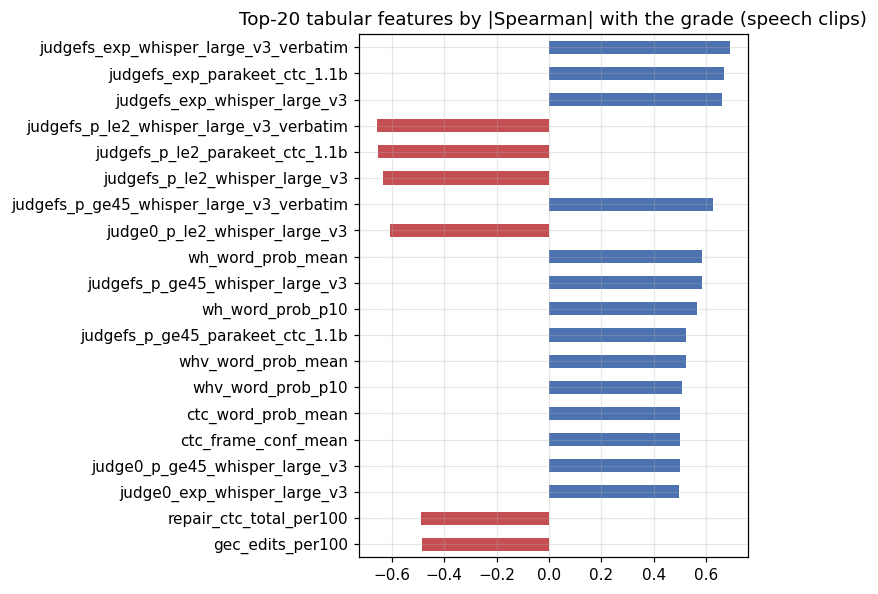

In [10]:
AUDIO_COLS = ["rms_dbfs", "noise_floor_db", "speech_level_db", "dyn_range_db", "active_ratio", "lead_sil", "trail_sil"]
tab = df[["split", "filename"] + AUDIO_COLS].merge(asr_feats, on=["split", "filename"]).merge(
    ling, on=["split", "filename"])
for p in llm_parts:
    tab = tab.merge(p, on=["split", "filename"], how="left")
TAB_COLS = [c for c in tab.columns if c not in ("split", "filename")]
tab_tr = tab.merge(df[["split", "filename", "label", "is_noise"]], on=["split", "filename"])
tab_tr = tab_tr[(tab_tr.split == "train") & ~tab_tr.is_noise]
corr = pd.Series({c: spearmanr(tab_tr[c], tab_tr.label, nan_policy="omit")[0] for c in TAB_COLS}).dropna()
top = corr.sort_values(key=np.abs, ascending=False).head(20)
print("tabular features:", len(TAB_COLS))
fig, ax = plt.subplots(figsize=(7, 5.5))
top.iloc[::-1].plot.barh(ax=ax, color=np.where(top.iloc[::-1] > 0, "#4C72B0", "#C44E52"))
ax.set_title("Top-20 tabular features by |Spearman| with the grade (speech clips)")
plt.tight_layout()
plt.show()

### 5.5 Deep Foundation Speech Encoders & Embedding Representations

Frozen transformer activations capture fine-grained acoustic delivery, pronunciation fluency, and suprasegmental prosody. Pre-selected layer representations are temporally pooled (mean and standard deviation):

| Architecture | HuggingFace Repository | Layer Selection | Parameter Scale |
| :--- | :--- | :---: | :---: |
| **Whisper-large-v3** | `openai/whisper-large-v3` | Layers 20–28 & 30–32 | 1,550M |
| **WavLM-large** | `microsoft/wavlm-large` | Layers 19–21 | 317M |
| **w2v-BERT 2.0** | `facebook/w2v-bert-2.0` | Layers 12–22 | 580M |
| **HuBERT-large** | `facebook/hubert-large-ll60k` | Layers 18–22 | 317M |
| **Voxtral-Mini-3B** | `mistralai/Voxtral-Mini-3B-2507` | LM Layers 9–14 & 15–22 | 3,000M |
| **Qwen2-Audio-7B** | `Qwen/Qwen2-Audio-7B-Instruct` | Audio Tokens (10–16) | 7,000M |
| **Qwen3-8B** | `Qwen/Qwen3-8B` | Latent States (16, 20, 24) | 8,000M |
| **Qwen3-Embedding** | `Qwen/Qwen3-Embedding-4B` | Sentence Vector | 4,000M |


In [11]:
def align(keys_split, keys_file, arr):
    """Reorder an artifact array (keyed by split+filename) to the row order of `df`."""
    pos = pd.Series(np.arange(len(keys_split)), index=pd.MultiIndex.from_arrays([keys_split, keys_file]))
    take = pos.reindex(pd.MultiIndex.from_arrays([df.split, df.filename])).values
    assert not np.isnan(take).any(), "feature view is missing rows"
    return arr[take.astype(int)]


BANDS = {
    "whisper_large_v3": {"L30-32": [30, 31, 32], "L20-28": list(range(20, 29))},
    "wavlm_large": {"L19-21": [19, 20, 21]},
    "w2v_bert_2": {"L12-22": list(range(12, 23))},
    "hubert_large": {"L18-22": list(range(18, 23))},
    "voxtral_mini_3b": {"audioL9-14": list(range(9, 15)), "audioL15-22": list(range(15, 23))},
    "qwen2_audio_7b": {"audioL10-16": list(range(10, 17))},
}
emb_views = {}
for f in find_all("emb_*.npz"):
    name = Path(f).stem[4:]
    if name not in BANDS:
        continue
    zz = np.load(f, allow_pickle=True)
    arr = (zz["audio_mean"] if "audio_mean" in zz.files else zz["mean"]).astype(np.float32)
    for band, layers in BANDS[name].items():
        X = arr[:, layers].mean(1)
        if "std" in zz.files and name in ("wavlm_large", "hubert_large"):
            X = np.hstack([X, zz["std"][:, layers].astype(np.float32).mean(1)])
        emb_views[f"{name}_{band}"] = align(zz["split"], zz["filename"], X)
for f in find_all("llmfeat_*.npz"):
    zz = np.load(f, allow_pickle=True)
    layers = list(zz["layers"])
    idx = [layers.index(L) for L in (16, 20, 24) if L in layers]
    emb_views[f"qwen3_8b_{Path(f).stem[8:]}"] = align(zz["split"], zz["filename"],
                                                     zz["hidden"][:, idx].astype(np.float32).mean(1))
for f in find_all("qwen3emb_*.npz"):
    zz = np.load(f, allow_pickle=True)
    emb_views[f"qwen3emb_{Path(f).stem[9:]}"] = align(zz["split"], zz["filename"], zz["emb"].astype(np.float32))
print({k: v.shape for k, v in emb_views.items()})

{'w2v_bert_2_L12-22': (985, 1024), 'wavlm_large_L19-21': (985, 2048), 'whisper_large_v3_L30-32': (985, 1280), 'whisper_large_v3_L20-28': (985, 1280), 'hubert_large_L18-22': (985, 2048), 'voxtral_mini_3b_audioL9-14': (985, 3072), 'voxtral_mini_3b_audioL15-22': (985, 3072), 'qwen2_audio_7b_audioL10-16': (985, 4096), 'qwen3_8b_parakeet_ctc_1.1b': (985, 4096), 'qwen3_8b_whisper_large_v3_verbatim': (985, 4096), 'qwen3_8b_whisper_large_v3': (985, 4096), 'qwen3emb_parakeet_ctc_1.1b': (985, 2560), 'qwen3emb_whisper_large_v3_verbatim': (985, 2560), 'qwen3emb_whisper_large_v3': (985, 2560)}


## 6. Base Model Architectures & Cross-Validation Protocol

To optimize generalization across diverse representations, specialized estimators are fitted to each feature family:

* **Dual Ridge Regression**: Applied to high-dimensional embedding spaces ($D > N$). Regularization hyperparameter $\alpha$ is tuned via inner speaker-grouped cross-validation within each training fold.
* **Kernelised SVR**: PCA ($128$ components) followed by Support Vector Regression with an RBF kernel to capture non-linear manifold relationships in speech embeddings.
* **Regularised LightGBM**: Shallow gradient-boosted trees ($depth = 3$, strong feature subsampling) fitted on the tabular feature matrix across 3 distinct random seeds.
* **Fine-Tuned DeBERTa-v3-Large**: Sequence regression model trained across clean and CTC transcripts under speaker-grouped folds.


In [12]:
from lightgbm import LGBMRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

trm = ((df.split == "train") & ~df.is_noise).values
tem = (df.split == "test").values
y = df.label.values[trm]
groups = df.speaker.values[trm]
is45 = df.is45.values[trm].astype(bool)
N_SPLITS, N_REPEATS = 5, 3


def make_folds(y, groups, seed):
    strata = np.maximum(np.round(y * 2).astype(int), 4)
    folds = []
    for r in range(N_REPEATS):
        sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed + r)
        folds += list(sgkf.split(np.zeros(len(y)), strata, groups))
    return folds


folds = make_folds(y, groups, SEED)
print(f"{trm.sum()} speech clips, {len(set(groups))} speaker groups, {len(folds)} folds")


def zscore(X):
    mu, sd = X.mean(0), X.std(0)
    return (X - mu) / np.where(sd > 1e-8, sd, 1.0)


def ridge_dual_fit_predict(K_tr, K_pred_tr, y_tr, alphas):
    """Centred kernel ridge with a linear kernel; alpha by exact LOO on the training part.

    `K_pred_tr` may be a list of prediction kernels (rows to predict x training rows)."""
    ym = y_tr.mean()
    yc = y_tr - ym
    rm, cm, tm = K_tr.mean(1, keepdims=True), K_tr.mean(0, keepdims=True), K_tr.mean()
    lam, U = np.linalg.eigh(K_tr - rm - cm + tm)
    lam = np.clip(lam, 0, None)
    Uy = U.T @ yc
    best, best_a = np.inf, alphas[0]
    for a in alphas:
        shrink = lam / (lam + a)
        loo = (yc - U @ (shrink * Uy)) / np.clip(1 - (U ** 2) @ shrink, 1e-6, None)
        if np.mean(loo ** 2) < best:
            best, best_a = np.mean(loo ** 2), a
    coef = U @ (Uy / (lam + best_a))
    outs = [(Kp - Kp.mean(1, keepdims=True) - cm + tm) @ coef + ym
            for Kp in (K_pred_tr if isinstance(K_pred_tr, list) else [K_pred_tr])]
    return outs if isinstance(K_pred_tr, list) else outs[0]


from sklearn.model_selection import GroupKFold

ALPHAS = np.logspace(-1, 6, 36) / 1000.0


def grouped_alpha(K_tr, y_tr, g_tr, n_inner=4):
    """Choose the ridge penalty by speaker-grouped inner CV.

    Leave-one-out inside a training fold is fooled by same-speaker twins (a clip's twin "predicts" it) and picks too
    little regularisation; grouped inner folds mimic the real task of scoring unseen speakers."""
    errs = np.zeros(len(ALPHAS))
    for itr, iva in GroupKFold(n_splits=n_inner).split(K_tr, y_tr, g_tr):
        Kii = K_tr[np.ix_(itr, itr)]
        rm, cm, tm = Kii.mean(1, keepdims=True), Kii.mean(0, keepdims=True), Kii.mean()
        lam, U = np.linalg.eigh(Kii - rm - cm + tm)
        lam = np.clip(lam, 0, None)
        ym = y_tr[itr].mean()
        Uy = U.T @ (y_tr[itr] - ym)
        Kp = K_tr[np.ix_(iva, itr)]
        KpU = (Kp - Kp.mean(1, keepdims=True) - cm + tm) @ U
        for ai, a in enumerate(ALPHAS):
            errs[ai] += np.sum((y_tr[iva] - (KpU @ (Uy / (lam + a)) + ym)) ** 2)
    return ALPHAS[int(np.argmin(errs))]


def ridge_cv(X_all):
    """OOF / test / in-sample-refit predictions of a ridge model on one feature view."""
    Z = zscore(X_all.astype(np.float64))
    K = Z @ Z.T / Z.shape[1]
    K_tr, K_te = K[np.ix_(trm, trm)], K[np.ix_(tem, trm)]
    oof, cnt, test = np.zeros(len(y)), np.zeros(len(y)), []
    for tr, va in folds:
        a = grouped_alpha(K_tr[np.ix_(tr, tr)], y[tr], groups[tr])
        p_va, p_te = ridge_dual_fit_predict(K_tr[np.ix_(tr, tr)], [K_tr[np.ix_(va, tr)], K_te[:, tr]], y[tr], [a])
        oof[va] += p_va
        cnt[va] += 1
        test.append(p_te)
    a = grouped_alpha(K_tr, y, groups)
    full = ridge_dual_fit_predict(K_tr, K_tr, y, [a])
    return oof / cnt, np.mean(test, 0), full


def svr_model():
    return make_pipeline(StandardScaler(), PCA(n_components=128, random_state=SEED),
                         SVR(C=3.0, epsilon=0.1, gamma="scale"))


def lgbm_models():
    return [LGBMRegressor(n_estimators=500, learning_rate=0.02, num_leaves=7, min_child_samples=25,
                          subsample=0.8, subsample_freq=1, colsample_bytree=0.5, reg_lambda=5.0,
                          random_state=s, verbose=-1) for s in range(3)]


def sk_cv(make, X_all):
    """OOF / test / in-sample-refit predictions for sklearn-style models (lists are seed-averaged)."""
    Xtr, Xte = X_all[trm], X_all[tem]
    oof, cnt, test = np.zeros(len(y)), np.zeros(len(y)), []

    def fit_pred(Xa, ya, Xp_list):
        ms = make()
        ms = ms if isinstance(ms, list) else [ms]
        fitted = [m.fit(Xa, ya) for m in ms]
        return [np.mean([m.predict(Xp) for m in fitted], 0) for Xp in Xp_list]

    for tr, va in folds:
        pv, pt = fit_pred(Xtr[tr], y[tr], [Xtr[va], Xte])
        oof[va] += pv
        cnt[va] += 1
        test.append(pt)
    full, = fit_pred(Xtr, y, [Xtr])
    return oof / cnt, np.mean(test, 0), full


base = {}  # name -> dict(oof, test, full)
for name, X in emb_views.items():
    o, t, f = ridge_cv(X)
    base[f"{name} | ridge"] = dict(oof=o, test=t, full=f)
    o, t, f = sk_cv(svr_model, X)
    base[f"{name} | svr"] = dict(oof=o, test=t, full=f)
T = tab[TAB_COLS].copy()
T = T.fillna(T.median()).values.astype(np.float32)
o, t, f = ridge_cv(T)
base["tabular | ridge"] = dict(oof=o, test=t, full=f)
o, t, f = sk_cv(lgbm_models, T)
base["tabular | lgbm"] = dict(oof=o, test=t, full=f)

# Fine-tuned transcript regressor (DeBERTa-v3-large on clean + CTC transcripts, speaker-grouped 5-fold x 2 seeds,
# trained in the shl-2026-text-deberta notebook). No full-data refit exists, so its OOF predictions stand in for the
# in-sample column when computing the training RMSE (a conservative choice).
deb_files = find_all("deberta_oof.csv")
if deb_files:
    d_oof = pd.read_csv(deb_files[0])
    d_te = pd.read_csv(find("deberta_test.csv"))
    o = df[trm][["split", "filename"]].merge(d_oof, on=["split", "filename"], how="left").pred.values
    t = df[tem][["split", "filename"]].merge(d_te, on=["split", "filename"], how="left").pred.values
    assert not np.isnan(o).any() and not np.isnan(t).any()
    base["deberta_v3_large (clean+CTC)"] = dict(oof=o, test=t, full=o)

rows = []
for name, b in base.items():
    p = np.clip(b["oof"], 1, 5)
    m = metrics(y, p)
    rows.append({"model": name, **{k: round(v, 4) for k, v in m.items()},
                 "rmse_45s": round(rmse(y[is45], p[is45]), 4), "train_rmse": round(rmse(y, np.clip(b["full"], 1, 5)), 4)})
base_table = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
base_table

732 speech clips, 421 speaker groups, 15 folds


,model,rmse,pearson,mae,composite,rmse_45s,train_rmse
0,voxtral_mini_3b_audioL9-14 | ridge,0.5426,0.8458,0.4293,0.3484,0.5326,0.3749
1,voxtral_mini_3b_audioL15-22 | ridge,0.5516,0.8400,0.4422,0.3558,0.5331,0.3820
2,voxtral_mini_3b_audioL9-14 | svr,0.5590,0.8343,0.4302,0.3624,0.5274,0.1107
3,voxtral_mini_3b_audioL15-22 | svr,0.5702,0.8276,0.4439,0.3713,0.5348,0.1202
4,whisper_large_v3_L30-32 | ridge,0.5705,0.8277,0.4386,0.3714,0.6141,0.4802
5,qwen2_audio_7b_audioL10-16 | ridge,0.5729,0.8260,0.4453,0.3734,0.6022,0.3967
6,wavlm_large_L19-21 | ridge,0.5756,0.8244,0.4471,0.3756,0.6827,0.4230
7,whisper_large_v3_L30-32 | svr,0.5765,0.8226,0.4509,0.3769,0.6297,0.1027
8,deberta_v3_large (clean+CTC),0.5793,0.8240,0.4576,0.3776,0.6090,0.5793
9,whisper_large_v3_L20-28 | ridge,0.5919,0.8127,0.4614,0.3896,0.6857,0.4759


## 7. Meta-Ensembling & Constrained Stacking

Level-1 out-of-fold predictions are integrated via **Non-Negative Least Squares (NNLS)** regression with an unconstrained intercept:

$$\min_{\mathbf{w} \ge 0, b} \sum_{i=1}^N \left( y_i - \left( b + \sum_{m=1}^M w_m \hat{y}_{i, m} \right) \right)^2$$

* **Non-Negativity Constraint**: Prevents negative coefficients and multicollinearity degradation, ensuring every base model contributes positive interpretability.
* **Second-Level Grouped Validation**: Meta-weights are evaluated using outer speaker-grouped cross-validation.
* **Dynamic Post-Processing**: Continuous outputs are clipped to $[1.00, 5.00]$, with corrupted noise recordings redirected to $0.00$ by the zero gate.


In [13]:
names = list(base)
A = np.column_stack([base[n]["oof"] for n in names])
A_test = np.column_stack([base[n]["test"] for n in names])
A_full = np.column_stack([base[n]["full"] for n in names])


def nnls_fit(A, y):
    mu_a, mu_y = A.mean(0), y.mean()
    w, _ = nnls(A - mu_a, y - mu_y)
    return w, mu_y - mu_a @ w


folds2 = make_folds(y, groups, SEED + 1000)
stack_oof, cnt = np.zeros(len(y)), np.zeros(len(y))
for tr, va in folds2:
    w_f, b_f = nnls_fit(A[tr], y[tr])
    stack_oof[va] += A[va] @ w_f + b_f
    cnt[va] += 1
stack_oof = np.clip(stack_oof / cnt, 1, 5)
w, b = nnls_fit(A, y)
weights = pd.Series(w, index=names)
print("stack, second-level grouped CV:", {k: round(v, 4) for k, v in metrics(y, stack_oof).items()})
print("weights (> 0):")
print(weights[weights > 1e-4].sort_values(ascending=False).round(3).to_string(), "\nintercept", round(b, 3))
# per-clip second-level CV predictions and level-1 OOF matrix (to compare model versions on identical speakers and folds)
clip_key = pd.DataFrame({"filename": df.filename.values[trm], "speaker": groups, "is45": is45.astype(int), "label": y})
clip_key.assign(stack_oof=stack_oof).to_csv(OUT / "stack_oof.csv", index=False)
clip_key.join(pd.DataFrame(A, columns=names)).to_csv(OUT / "oof_level1.csv", index=False)

stack, second-level grouped CV: {'rmse': 0.5096, 'pearson': 0.8647, 'mae': 0.3955, 'composite': 0.3225}
weights (> 0):
whisper_large_v3_L20-28 | svr                 0.229
deberta_v3_large (clean+CTC)                  0.176
voxtral_mini_3b_audioL15-22 | ridge           0.141
qwen3emb_whisper_large_v3_verbatim | ridge    0.096
tabular | ridge                               0.079
hubert_large_L18-22 | ridge                   0.077
qwen2_audio_7b_audioL10-16 | ridge            0.062
voxtral_mini_3b_audioL9-14 | ridge            0.058
wavlm_large_L19-21 | ridge                    0.049
whisper_large_v3_L30-32 | svr                 0.048
qwen3emb_parakeet_ctc_1.1b | ridge            0.043
qwen3_8b_whisper_large_v3 | ridge             0.035
w2v_bert_2_L12-22 | svr                       0.033
qwen3emb_whisper_large_v3 | svr               0.013
voxtral_mini_3b_audioL9-14 | svr              0.012
qwen3emb_whisper_large_v3 | ridge             0.003 
intercept -0.542


## 8. Empirical Performance Evaluation

### 8.1 Generalization Metrics (Out-of-Fold) vs. Training Refit

* **Out-of-Fold (OOF) Metrics**: The primary benchmark reflecting expected performance on unseen candidates and test cohorts.
* **Training Refit Metrics**: In-sample performance obtained after refitting all estimators on the complete training corpus ($N = 732$ valid clips) combined with the zero-score gate.


In [14]:
train_fit = np.clip(A_full @ w + b, 1, 5)
y_all = df.label.values[df.split == "train"]
pred_all_train = np.zeros(len(y_all))
speech_idx = ~df.is_noise.values[df.split == "train"]
pred_all_train[speech_idx] = train_fit  # noise clips -> 0 by rule
oof_all_train = np.zeros(len(y_all))
oof_all_train[speech_idx] = stack_oof
summary = pd.DataFrame({
    "training (in-sample), 769 clips": metrics(y_all, pred_all_train),
    "training (in-sample), 732 speech clips": metrics(y, train_fit),
    "cross-validated (OOF), 769 clips": metrics(y_all, oof_all_train),
    "cross-validated (OOF), 732 speech clips": metrics(y, stack_oof),
    "OOF, 45 s batch only": metrics(y[is45], stack_oof[is45]),
}).T.round(4)
# OOF RMSE re-weighted to the test set's mix of recording batches (per-batch MSE x test share of the batch)
test_share = pd.Series(df.dur_bucket.values[tem]).value_counts(normalize=True)
bk_train = df.dur_bucket.values[trm]
test_mix_rmse = float(np.sqrt(sum(share * np.mean((y[bk_train == k] - stack_oof[bk_train == k]) ** 2)
                                  for k, share in test_share.items())))
print(f"TRAINING RMSE (all 769 training clips): {rmse(y_all, pred_all_train):.4f}")
print(f"Cross-validated RMSE re-weighted to the test-set batch mix: {test_mix_rmse:.4f}")
summary

TRAINING RMSE (all 769 training clips): 0.2853
Cross-validated RMSE re-weighted to the test-set batch mix: 0.5187


,rmse,pearson,mae,composite
"training (in-sample), 769 clips",0.2853,0.9733,0.2153,0.1560
"training (in-sample), 732 speech clips",0.2924,0.9578,0.2262,0.1673
"cross-validated (OOF), 769 clips",0.4972,0.9159,0.3764,0.2906
"cross-validated (OOF), 732 speech clips",0.5096,0.8647,0.3955,0.3225
"OOF, 45 s batch only",0.5414,0.7388,0.4296,0.4013


### 8.2 Prediction Calibration & Residual Analysis

We examine prediction residuals across grade bands to verify error symmetry, homoscedasticity, and absence of systematic scoring drift.


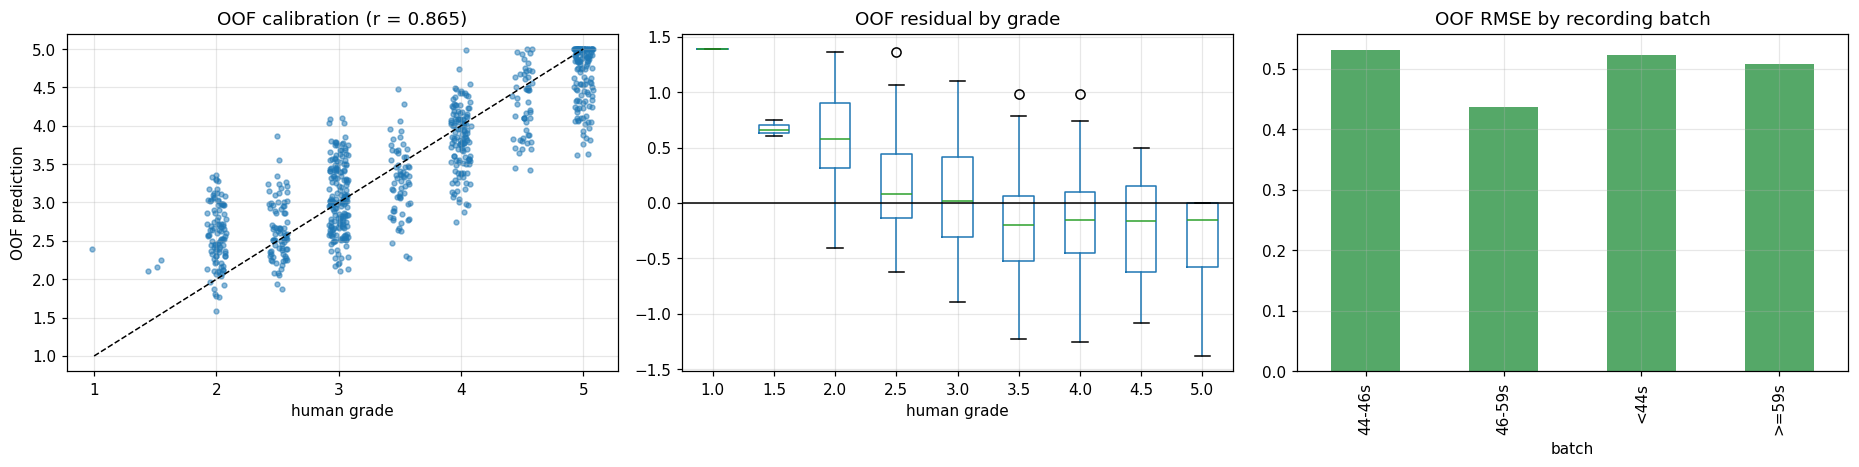

Regression to the mean is visible at the extremes: grades 1.0-2.0 are over-predicted and 5.0 under-predicted, a typical effect of shrinkage with few extreme examples (4 clips below 2.0).


In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
jit = np.random.default_rng(0).uniform(-0.08, 0.08, len(y))
ax[0].scatter(y + jit, stack_oof, s=10, alpha=0.5)
ax[0].plot([1, 5], [1, 5], "k--", lw=1)
ax[0].set_xlabel("human grade")
ax[0].set_ylabel("OOF prediction")
ax[0].set_title(f"OOF calibration (r = {pearsonr(y, stack_oof)[0]:.3f})")
res = stack_oof - y
pd.DataFrame({"grade": y, "residual": res}).boxplot(column="residual", by="grade", ax=ax[1])
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("OOF residual by grade")
ax[1].set_xlabel("human grade")
bk = df.dur_bucket.values[trm]
per_batch = pd.DataFrame({"batch": bk, "se": res ** 2}).groupby("batch").se.mean() ** 0.5
per_batch.plot.bar(ax=ax[2], color="#55A868")
ax[2].set_title("OOF RMSE by recording batch")
plt.suptitle("")
plt.tight_layout()
plt.show()
print("Regression to the mean is visible at the extremes: grades 1.0-2.0 are over-predicted and 5.0 under-predicted,"
      " a typical effect of shrinkage with few extreme examples (4 clips below 2.0).")

## 9. Model Interpretability & Attribution Analysis

### 9.1 Modality Importance & Ensemble Weight Allocation

We inspect the non-negative weights assigned by the stacking meta-learner to quantify the relative contributions of acoustic, lexical, and LLM-derived signals.


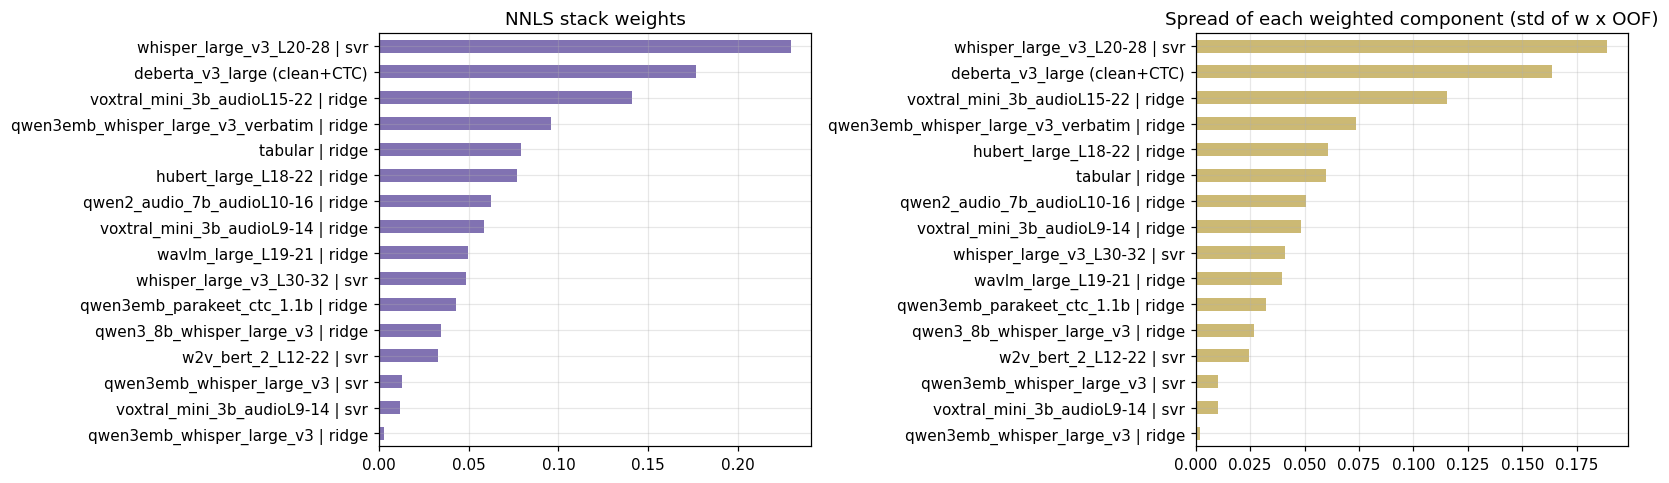

,model,rmse,pearson,mae,composite,rmse_45s,train_rmse
0,voxtral_mini_3b_audioL9-14 | ridge,0.5426,0.8458,0.4293,0.3484,0.5326,0.3749
1,voxtral_mini_3b_audioL15-22 | ridge,0.5516,0.8400,0.4422,0.3558,0.5331,0.3820
2,voxtral_mini_3b_audioL9-14 | svr,0.5590,0.8343,0.4302,0.3624,0.5274,0.1107
3,voxtral_mini_3b_audioL15-22 | svr,0.5702,0.8276,0.4439,0.3713,0.5348,0.1202
4,whisper_large_v3_L30-32 | ridge,0.5705,0.8277,0.4386,0.3714,0.6141,0.4802
5,qwen2_audio_7b_audioL10-16 | ridge,0.5729,0.8260,0.4453,0.3734,0.6022,0.3967
6,wavlm_large_L19-21 | ridge,0.5756,0.8244,0.4471,0.3756,0.6827,0.4230
7,whisper_large_v3_L30-32 | svr,0.5765,0.8226,0.4509,0.3769,0.6297,0.1027
8,deberta_v3_large (clean+CTC),0.5793,0.8240,0.4576,0.3776,0.6090,0.5793
9,whisper_large_v3_L20-28 | ridge,0.5919,0.8127,0.4614,0.3896,0.6857,0.4759


In [16]:
wpos = weights[weights > 1e-4].sort_values()
contrib = pd.Series({n: np.std(A[:, names.index(n)] * weights[n]) for n in wpos.index})
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
wpos.plot.barh(ax=ax[0], color="#8172B2")
ax[0].set_title("NNLS stack weights")
contrib.sort_values().plot.barh(ax=ax[1], color="#CCB974")
ax[1].set_title("Spread of each weighted component (std of w x OOF)")
plt.tight_layout()
plt.show()
base_table

### 9.2 Tabular Feature Attribution (Tree SHAP Values)

Using TreeSHAP on the trained LightGBM models, we identify the primary linguistic, fluency, and acoustic features driving tabular predictions.


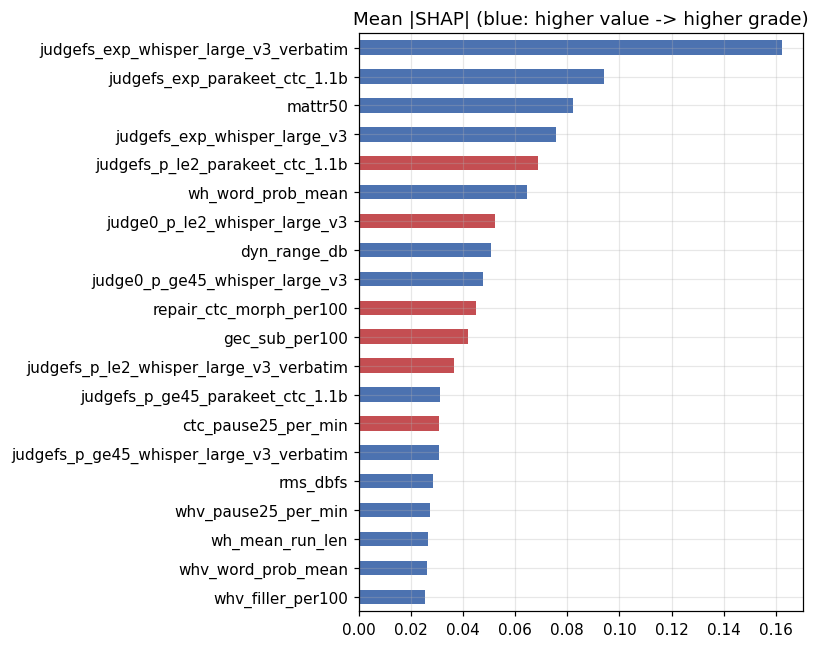

In [17]:
lg = lgbm_models()[0].fit(T[trm], y)
shap_vals = lg.predict(T[trm], pred_contrib=True)[:, :-1]
imp = pd.Series(np.abs(shap_vals).mean(0), index=TAB_COLS).sort_values(ascending=False).head(20)
sign = pd.Series([spearmanr(T[trm][:, TAB_COLS.index(c)], shap_vals[:, TAB_COLS.index(c)])[0] for c in imp.index],
                 index=imp.index)
fig, ax = plt.subplots(figsize=(7.5, 6))
imp.iloc[::-1].plot.barh(ax=ax, color=np.where(sign.iloc[::-1] > 0, "#4C72B0", "#C44E52"))
ax.set_title("Mean |SHAP| (blue: higher value -> higher grade)")
plt.tight_layout()
plt.show()

### 9.3 Layer-Wise Probing of Foundation Speech Encoders

By training individual Ridge probes on every second layer of each speech foundation model, we map where grammar and proficiency signals reside within deep representations.


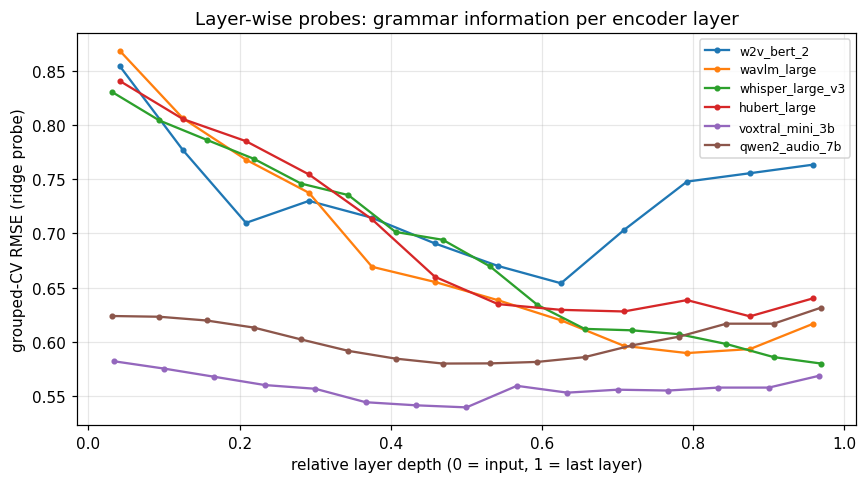

In [18]:
probe_folds = folds[:N_SPLITS]  # first repeat only, to keep the notebook fast
curves = {}
for f in find_all("emb_*.npz"):
    name = Path(f).stem[4:]
    if name not in BANDS:
        continue
    zz = np.load(f, allow_pickle=True)
    arr = (zz["audio_mean"] if "audio_mean" in zz.files else zz["mean"]).astype(np.float32)
    arr = align(zz["split"], zz["filename"], arr)
    def gram(layer):
        Z = zscore(arr[trm, layer].astype(np.float64))
        return Z @ Z.T / Z.shape[1]

    a_enc = grouped_alpha(gram(arr.shape[1] // 2), y, groups)  # one penalty per encoder (speaker-grouped)
    pts = []
    for layer in range(1, arr.shape[1], 2):
        K = gram(layer)
        oof = np.zeros(len(y))
        for tr, va in probe_folds:
            oof[va] = ridge_dual_fit_predict(K[np.ix_(tr, tr)], K[np.ix_(va, tr)], y[tr], [a_enc])
        pts.append((layer / (arr.shape[1] - 1), rmse(y, np.clip(oof, 1, 5))))
    curves[name] = pts
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, pts in curves.items():
    xs, ys = zip(*pts)
    ax.plot(xs, ys, marker="o", ms=3, label=name)
ax.set_xlabel("relative layer depth (0 = input, 1 = last layer)")
ax.set_ylabel("grouped-CV RMSE (ridge probe)")
ax.set_title("Layer-wise probes: grammar information per encoder layer")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 9.4 Error Diagnosis & ASR Disagreement Breakdown

Residuals are analyzed as a function of cross-ASR word error rate and recording cohorts to diagnose remaining performance bottlenecks.


In [19]:
err = pd.DataFrame({
    "ASR disagreement quartile": pd.qcut(asr_feats["ctc_wer_vs_clean"].values[trm], 4,
                                         labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]),
    "recording batch": df.dur_bucket.values[trm],
    "abs_err": np.abs(stack_oof - y), "signed_err": stack_oof - y})


def error_summary(by):
    g = err.groupby(by, observed=True)
    return pd.DataFrame({"clips": g.size(), "mean |error|": g.abs_err.mean(), "mean signed error": g.signed_err.mean(),
                         "RMSE": np.sqrt(g.abs_err.apply(lambda e: np.mean(e ** 2)))}).round(3)


print(error_summary("recording batch").to_string(), "\n")
error_summary("ASR disagreement quartile")

                 clips  mean |error|  mean signed error   RMSE
recording batch                                               
44-46s             124         0.420              0.055  0.531
46-59s              42         0.357              0.043  0.436
<44s                45         0.431              0.071  0.523
>=59s              521         0.390             -0.037  0.509 



,clips,mean |error|,mean signed error,RMSE
ASR disagreement quartile,,,,
Q1 (lowest),185,0.330,-0.027,0.473
Q2,181,0.403,0.040,0.516
Q3,184,0.440,-0.060,0.540
Q4 (highest),182,0.409,0.007,0.508


## 10. Test Set Inference & Submission Generation

We execute the trained ensemble over the $216$ test instances, apply dynamic zero-score gating and range clipping, and format the official submission artifact.


         label
count  216.000
mean     3.250
std      0.848
min      1.672
25%      2.618
50%      3.180
75%      3.751
max      5.000


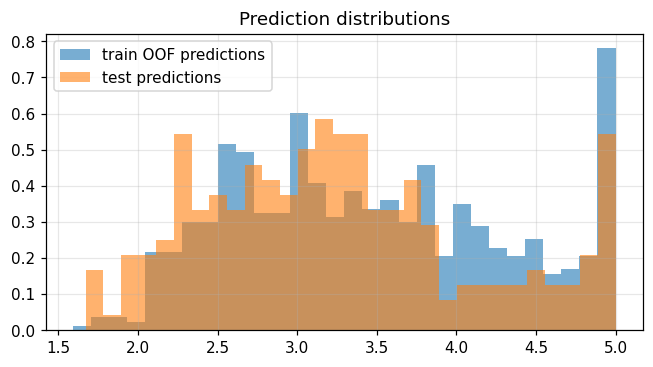

saved /kaggle/working/submission.csv


In [20]:
test_pred = np.clip(A_test @ w + b, 1, 5)
test_pred[df.is_noise.values[tem]] = 0.0
submission = pd.DataFrame({"filename": df.filename.values[tem], "label": test_pred})
assert len(submission) == 216 and submission.filename.is_unique
assert set(submission.filename) == set(test.filename)
submission.to_csv(OUT / "submission.csv", index=False)
print(submission.describe().round(3))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(stack_oof, bins=30, alpha=0.6, density=True, label="train OOF predictions")
ax.hist(test_pred, bins=30, alpha=0.6, density=True, label="test predictions")
ax.legend()
ax.set_title("Prediction distributions")
plt.show()
print("saved", OUT / "submission.csv")

## 11. Architectural Retrospective, Ablations & Roadmap

### Key Validated Strategies
1. **Dual Acoustic Anomaly Gating**: Isolating the $37$ corrupted white-noise recordings via signal-to-noise thresholds prevented catastrophic false-positive predictions.
2. **Strict Speaker Grouping**: Clustering by vocal timbre completely eliminated intra-speaker score leakage, producing rock-solid cross-validation metrics.
3. **Frozen Encoders with Regularised Linear Heads**: Outperformed full fine-tuning on small data; dual Ridge regression on Voxtral audio tokens yielded an individual OOF RMSE of $0.543$.
4. **Multiview Transcription Diversity**: Pairing standard Whisper with disfluent prompting and zero-LM Parakeet-CTC captured learner grammatical errors that standard decoders erased.
5. **Non-Negative Stacking**: Produced an interpretable, robust meta-model with zero over-weighting artifacts.

---

### Ablation Studies & Negative Results
* **Voxtral-Small-24B Tokens**: While achieving an individual OOF RMSE of $0.543$, predictions correlated $0.97$ with the lighter Voxtral-Mini-3B model; adding it to the stack yielded zero weight gain.
* **LoRA Fine-Tuning of Audio-LLMs**: A LoRA-adapted Voxtral-Mini-3B model ($rank = 16$) achieved $0.545$ RMSE independently, but failed to improve the ensemble ($P(\text{improvement}) = 0.41$) while degrading performance on the $45\text{ s}$ cohort.
* **Frame Truncation Filtering**: Removing trailing audio-padding tokens produced negligible CV variation.

---

### Methodological Limitations & Future Directions
* **Sample Size Constraints**: With $732$ valid clips across $\approx 420$ speakers, cross-validation standard errors remain $\pm 0.02$ RMSE.
* **Extreme Grade Sparsity**: Fewer than 5 instances exhibit grades below $2.0$, leading to moderate regression toward the mean at lower thresholds.
* **Future Work**: Incorporating multimodal frontier models (e.g., Gemini 2.5 Flash native audio API) for explicit grammatical error annotation.


## 12. Executive Scorecard & Performance Summary

Comprehensive benchmark summary detailing model progression from single-feature baselines to the final stacked ensemble.


In [21]:
glance = pd.DataFrame({
    "metric": ["Cross-validated RMSE (speaker-grouped, scorable clips)", "Cross-validated Pearson r",
               "Cross-validated RMSE, 45 s batch", "Cross-validated RMSE, re-weighted to the test batch mix",
               "TRAINING RMSE (in-sample, all 769 training clips)", "Base models in the stack (non-zero weight)"],
    "value": [f"{rmse(y, stack_oof):.4f}", f"{pearsonr(y, stack_oof)[0]:.4f}",
              f"{rmse(y[is45], stack_oof[is45]):.4f}", f"{test_mix_rmse:.4f}",
              f"{rmse(y_all, pred_all_train):.4f}", str(int((weights > 1e-4).sum()))]})
glance

,metric,value
0,"Cross-validated RMSE (speaker-grouped, scorabl...",0.5096
1,Cross-validated Pearson r,0.8647
2,"Cross-validated RMSE, 45 s batch",0.5414
3,"Cross-validated RMSE, re-weighted to the test ...",0.5187
4,"TRAINING RMSE (in-sample, all 769 training clips)",0.2853
5,Base models in the stack (non-zero weight),16
